# Optimization Paper Figures

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

In [2]:
from examples.airspacelib.wildfireresponse.environment import sim_properties
from examples.airspacelib.wildfireresponse.wildfiresim import WildfireSim, def_p, create_scen_sample, BasePlacementProblem
from examples.airspacelib.wildfireresponse.wildfiresim import WildFireSimParameter
from examples.airspacelib.wildfireresponse.aircraft import FireAircraft
from examples.airspacelib.wildfireresponse.environment import FireEnvironment, double_size_p
from fmdtools.sim import propagate
from fmdtools.analyze.common import consolidate_legend
from fmdtools.define.architecture.function import FunctionArchitectureGraph
from fmdtools.define.object.coords import Coords, CoordsParam
import numpy as np

In [3]:
traj_plot_kwar = dict(time="iter", time_ticks=1,  t_pretext="", time_groups=['nominal'])

Fire Propagation Map (with details)

In [4]:
def show_scen_strikes(fig=None, ax=None, color='blue', alpha=0.25, with_map=True, num_strikes=3,
                      **samp_kwargs):
    p = {**def_p}
    p['firemapparam']['num_strikes'] = num_strikes
    if with_map:
        mdl = WildfireSim(p=p)
        fig, ax = mdl.flows['fireenvironment'].c.show(properties=sim_properties,
                                                      fig=fig, ax=ax)
    ps = create_scen_sample(**samp_kwargs)
    props = {'strike': {"color": color, "alpha": alpha}}
    for scen in ps.scenarios():
        mdl = WildfireSim(p=p, r=scen.r, track=None)
        fig, ax = mdl.flows['fireenvironment'].c.show(properties=props, fig=fig, ax=ax)
    return fig, ax

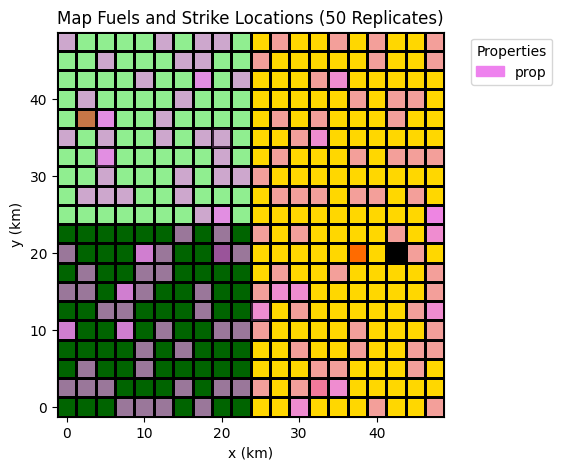

In [5]:
# average over all seeds:
fig, ax = show_scen_strikes(seed=10, color="violet", alpha=0.65, replicates=50)
ax.set_title("Map Fuels and Strike Locations (50 Replicates)")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
fig.savefig("map_and_strikes.pdf",  bbox_inches='tight')

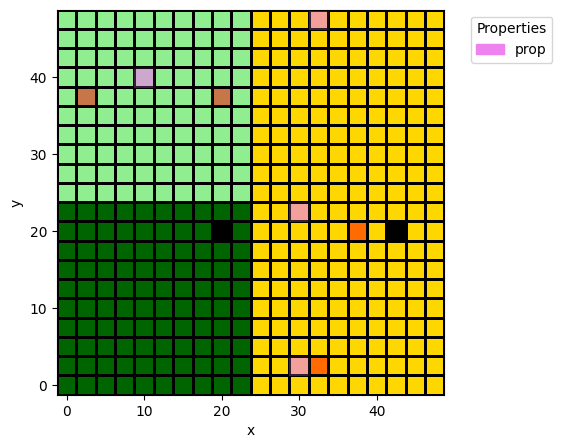

In [6]:
# one seed:
fig, ax = show_scen_strikes(seed=115, color="violet", alpha=0.65, replicates=1, num_strikes=4)

Aircraft procession though modes and states over time

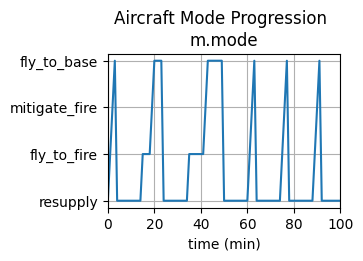

In [13]:
fe = FireEnvironment(c={"p": {**double_size_p, "base_locations": ((42.0, 20.0),)}})

a1 = FireAircraft(s={'goal_x': 30, 'goal_y': 40}, fireenvironment=fe, track="all")

res, hist = propagate.nominal(a1, protect=False)
fig, ax = hist.plot_line('m.mode', cols=1, title = "Aircraft Mode Progression", title_padding=0.1, xlabel="time (min)")
fig.savefig("aircraft_modes.pdf",  bbox_inches='tight')

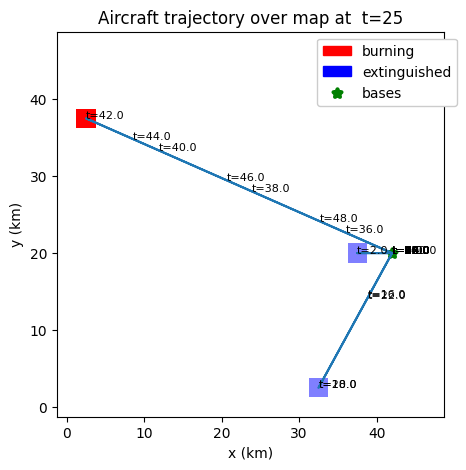

In [15]:
fig, ax = a1.fireenvironment.c.show_from(25, hist.fireenvironment.c,
                                             properties={'burning': {"color": "red", "as_bool": True}, "extinguished": {"color": "blue", "alpha": 0.5}},
                                             linewidth=0.0,
                                             title="Aircraft trajectory over map at ")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax, mark_time=True, time_ticks=2.0)
fig, ax = a1.fireenvironment.c.show_base_placement(fig, ax, color="green", loc="upper right", framealpha=1.0, title="Map Legend")

fig.savefig("aircraft_traj.pdf", bbox_inches='tight')

In [16]:
hist.s.retardant_status

array([100., 100., 100.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0., 100., 100., 100., 100., 100.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0., 100., 100., 100., 100., 100., 100., 100., 100.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0., 100., 100.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 100., 100.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0., 100., 100.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.])

In [17]:
hist

i.at_goal:                    array(101)
i.in_range:                   array(101)
m.mode:                       array(101)
m.sub_faults:                 array(101)
s.x:                          array(101)
s.goal_x:                     array(101)
s.dx:                         array(101)
s.y:                          array(101)
s.goal_y:                     array(101)
s.dy:                         array(101)
s.fuel_status:                array(101)
s.retardant_status:           array(101)
t.resupply.time:              array(101)
t.resupply.mode:              array(101)
fireenvironment.c.r.probdens: array(101)
fireenvironment.c.to_burn:    array(101)
fireenvironment.c.burning:    array(101)
fireenvironment.c.to_extinguish: array(101)
fireenvironment.c.extinguished: array(101)
time:                         array(101)

Structure of Fire Integrated Model

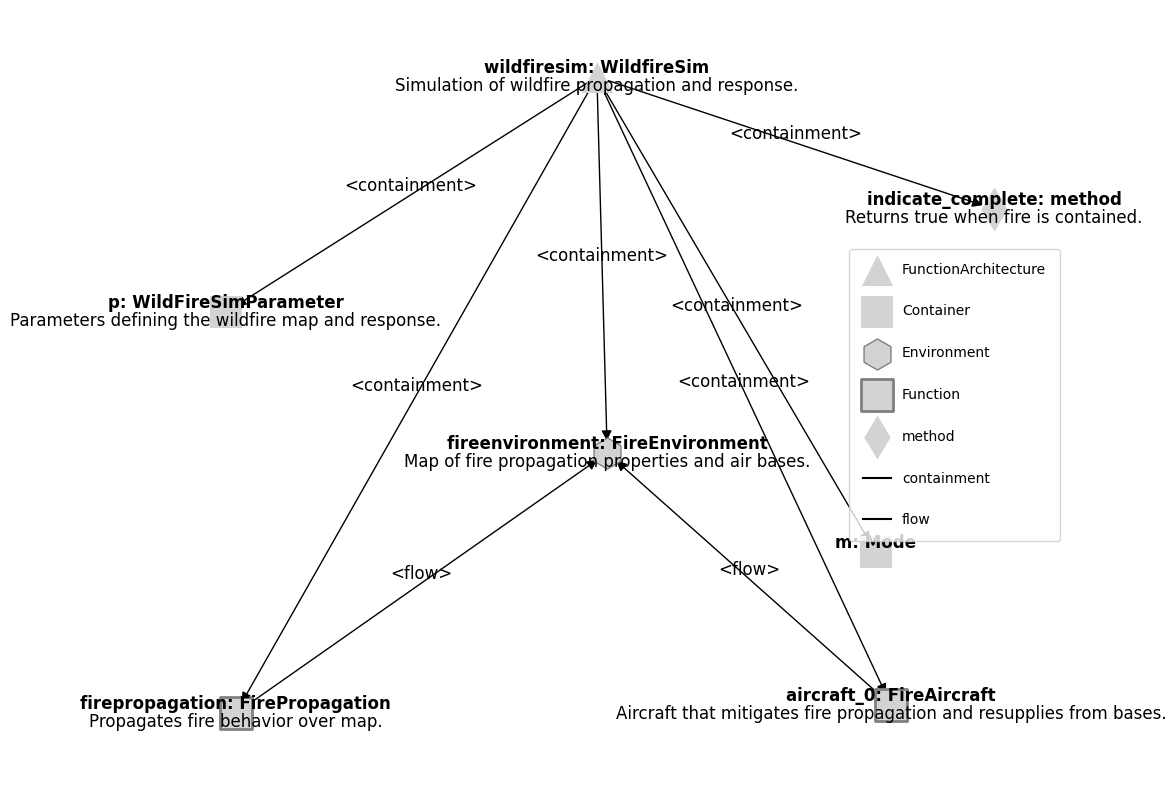

In [19]:

fg = FunctionArchitectureGraph(WildfireSim(), with_root=True, get_source=True)
fg.g.remove_nodes_from(["wildfiresim.sp", "wildfiresim.t", "wildfiresim.r"])
fg.set_node_labels(title="shortname", title2="classname", subtext="docs")
pos = {'wildfiresim': [0.05, 0.81], 'wildfiresim.flows.fireenvironment': [0.07, -0.1], 'wildfiresim.fxns.aircraft_0': [0.62, -0.71], 'wildfiresim.fxns.firepropagation': [-0.65, -0.73], 'wildfiresim.p': [-0.67, 0.24], 'wildfiresim.indicate_complete': [0.82, 0.49]}
#dot = fg.draw_graphviz(saveas="model_graph.pdf")
fig, ax = fg.draw(pos=pos, legend_bbox=(0.75,0.5))
fig.savefig("model_graph.pdf", bbox_inches='tight')

Combined propagation and mitigation of fire over time

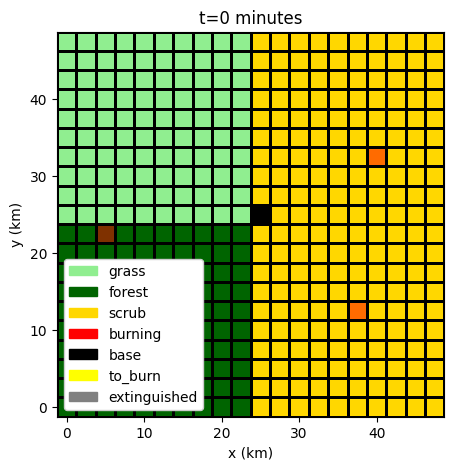

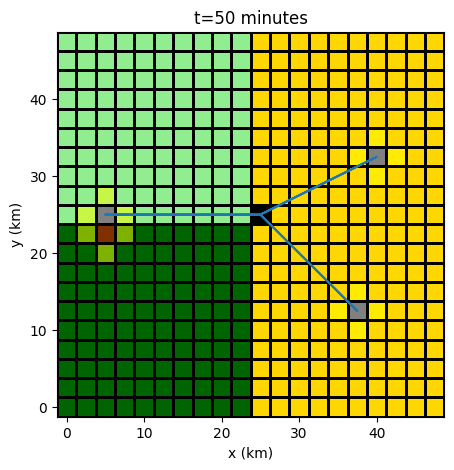

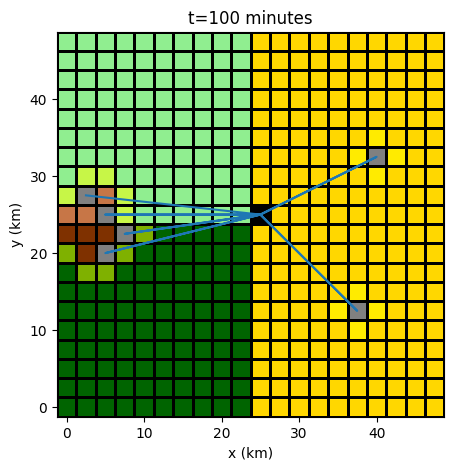

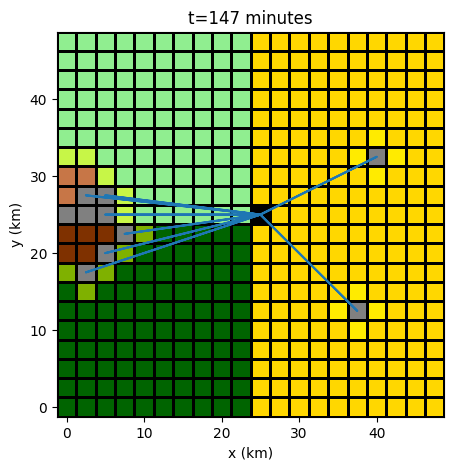

In [24]:
mdl = WildfireSim(p={"firemapparam": {**double_size_p, "base_locations": ((25.0, 25.0),)}}, r={'seed': 100})
res, hist = propagate.nominal(mdl, protect=False)
for i in [0, 50, 100, 147]:
    fig, ax = mdl.flows['fireenvironment'].c.show_from(i, hist.flows.fireenvironment.c, properties=sim_properties)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title("t="+str(i)+" minutes")
    if i != 0:
        ax.get_legend().remove()
    else:
        consolidate_legend(ax, bbox_to_anchor=(0,0), loc="lower left", framealpha=1.0)
    trunc_hist = hist.cut(i, newcopy=True)
    trunc_hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)
    fig.savefig("fireprop_t="+str(i)+".pdf", bbox_inches='tight')

Starting base configuration and results

In [42]:
class BurnedMapParam(CoordsParam):
    x_size: int = 20
    y_size: int = 20
    blocksize: float = 2.5


class BurnedMap(Coords):
    container_p = BurnedMapParam
    state_percent_burned: tuple = (float, 0.0)

    @classmethod
    def from_problem(cls, prob):
        bm = BurnedMap()
        bm.percent_burned = 100 * np.mean([*prob.res.get_values('burn_pts').values()], 0)
        return bm

In [88]:
psp = BasePlacementProblem(replicates=50, num_strikes=3, p={"firemapparam": double_size_p})

In [90]:
psp.perc_burned(25.0, 25.0)

np.float64(0.0799)

In [91]:
psp.perc_burned(23.75, 23.75)

np.float64(0.0767)

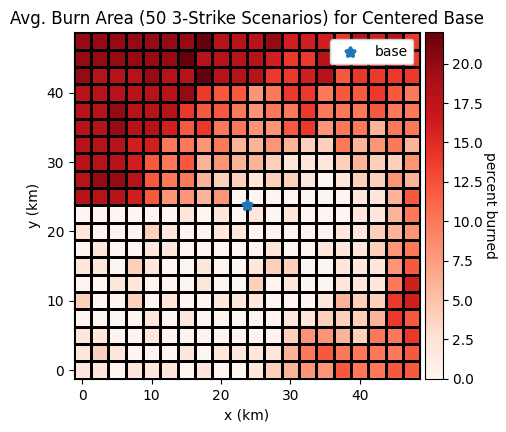

In [92]:
bm = BurnedMap.from_problem(psp)
fig, ax = bm.show(properties={'percent_burned': {'cmap': 'Reds'}},
                  title="Avg. Burn Area (50 3-Strike Scenarios) for Centered Base",
                  figsize=(5,4.5))
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.axis("square")
ax.collections[0].colorbar.set_label("percent burned", labelpad=10)
ax.scatter(23.75, 23.75, marker="*", label="base", linewidth=3.0)
ax.legend(framealpha=1.0)
fig.savefig("init_burn_area.pdf")
fig.savefig("init_burn_area.svg")

In [93]:
psp.perc_burned(25.37037037, 28.72839506)

np.float64(0.05315)

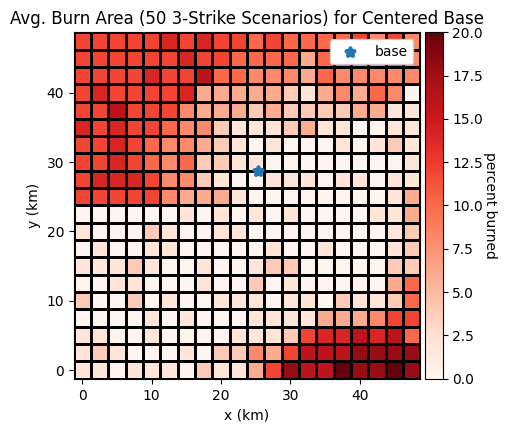

In [94]:
bm = BurnedMap.from_problem(psp)
fig, ax = bm.show(properties={'percent_burned': {'cmap': 'Reds'}},
                  title="Avg. Burn Area (50 3-Strike Scenarios) for Centered Base",
                  figsize=(5,4.5))
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.axis("square")
ax.collections[0].colorbar.set_label("percent burned", labelpad=10)
ax.scatter(25.37037037, 28.72839506, marker="*", label="base", linewidth=3.0)
ax.legend(framealpha=1.0)
fig.savefig("opt_burn_area.pdf")
fig.savefig("opt_burn_area.svg")

# Optimization 

In [ ]:
from scipy.optimize import minimize
from scipy.optimize import fmin_powell

def show_opt(ax, res, marker="*", color="red", text=True, linewidth=2.0, textcolor="red", fontsize=12, digits=3, **kwargs):
    ax.scatter(*res.x, marker=marker, color=color, linewidth=linewidth, zorder=10)
    if text:
        ax.annotate(str(round(res.fun, digits)), res.x, color=textcolor, fontsize=fontsize, **kwargs)

### Experiment 0: BFGS

BFGS Struggled at 10 replicates. At 20 replicates...

In [ ]:
import autograd.numpy as np
from autograd import grad, jacobian
from scipy.optimize._linesearch import line_search_armijo

def bfgs(x0, fun, grad, grad_threshold=1e-30, max_iter=100, n_linesearch=10):
    x = np.copy(x0)
    path = [np.copy(x0)]

    n_dims = x.shape[0]
    B = np.eye(n_dims)

    old_f = None

    g = grad(x)
    for _ in range(max_iter):
        p = np.linalg.solve(B, -g)

        alpha, n_feval, old_f = line_search_armijo(fun, x, p, g, old_f)
        if alpha is None:  # found no solution that satisfies the conditions
            alpha = 1.0

        s = alpha * p
        x += s

        prev_g = g
        g = grad(x)
        if np.linalg.norm(g) <= grad_threshold:
            break

        if prev_g is not None:
            y = g - prev_g
            B += (np.outer(y, y) / np.dot(y, s) -
                  B.dot(s[:, np.newaxis]).dot(s[np.newaxis, :]).dot(B) / s.dot(B).dot(s))

        path.append(np.copy(x))

    return x, path

In [ ]:
psp_bfgs = BasePlacementProblem(replicates=20)

def perc_burned_bfgs(x):
    if isinstance(x, np.ndarray) or isinstance(x, list):
        return psp_bfgs.perc_burned(*x)
    else:
        return psp_bfgs.perc_burned(*[*x._value])

In [ ]:
approx_grad = grad(perc_burned_bfgs)

Verifying gradient:

In [ ]:
approx_grad([15., 10.])

[array(0.), array(0.)]

So far, I haven't found a place where we can get a valid gradient from the sim. 

This may be because of the sim itself, or because of our optimization interface (?). I would guess any finite differencing (or similar)-type steps have a step size in here that is too small to actually work.

In [ ]:
x, path = bfgs([10., 10,], perc_burned_bfgs, approx_grad, max_iter=20)

In [ ]:
x

array([10., 10.])

In [ ]:
path

[array([10., 10.])]

So, this rules out BFGS until we have a good fix. Absent an easily-differentiable function, direct search methods are efficient means of optimization that use heuristics (often with rigourous backing theory) to explore the design space. The next few sections explore these methods...

### Experiment 1: Nelder-Mead

(Basically, it doesn't seem to work because of the weirdness of the objective.)

In [ ]:
initial_simplex = [[10.0, 10.0],[10.0, 40.0],[40.0, 40.0]]
psp_nm = BasePlacementProblem(replicates=20)
nm_res = minimize(perc_burned_nm, [10.0, 10.0], method="Nelder-Mead",
                    bounds=((-1.0, 47.), (-1.0, 47.)),
                    options=dict(initial_simplex=initial_simplex,
                             maxiter=50,
                             disp=True))
    
nm_res

Optimization terminated successfully.
         Current function value: 0.151125
         Iterations: 31
         Function evaluations: 86


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.151125
             x: [ 2.316e+01  3.580e+01]
           nit: 31
          nfev: 86
 final_simplex: (array([[ 2.316e+01,  3.580e+01],
                       [ 2.316e+01,  3.580e+01],
                       [ 2.316e+01,  3.580e+01]]), array([ 1.511e-01,  1.511e-01,  1.511e-01]))

In [ ]:
psp_nm.iter_hist.get_values('iter')

iter:                          array(86)

At 20 points, it seems to work okay (it didn't at 10).

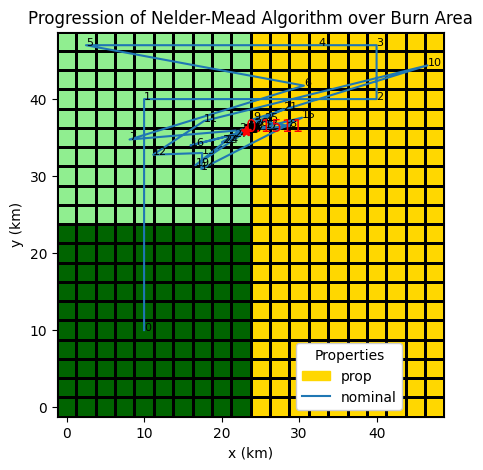

In [ ]:
fig, ax = psp_nm.mdl.flows['fireenvironment'].c.show(properties=show_properties)
fig, ax = psp_nm.iter_hist.plot_trajectories("variables.x", "variables.y", fig=fig, ax=ax, **traj_plot_kwar)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
show_opt(ax, nm_res, color="red", digits=4)
consolidate_legend(ax, bbox_to_anchor=(0.6,0), loc="lower left", framealpha=1.0)
ax.set_title("Progression of Nelder-Mead Algorithm over Burn Area")
fig.savefig("nelder_mead_progression.pdf", bbox_inches='tight')

In [ ]:
objs = psp_nm.iter_hist.objectives.perc_burned
psp_nm.iter_hist['min_obj'] = [np.min(objs[:i]) for i in range(1, len(objs)+1)]

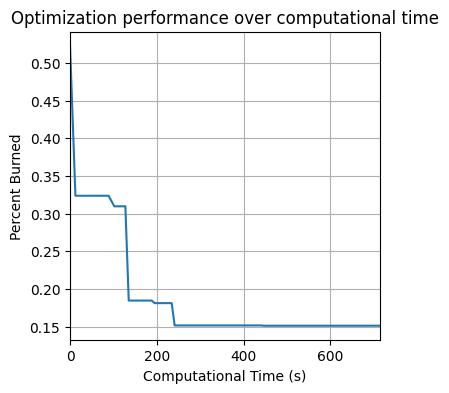

In [ ]:
fig, ax = psp_nm.iter_hist.plot_line("min_obj",
                                     ylabels={'min_obj': "Percent Burned"},
                                     xlabel="Computational Time (s)",
                                     figsize = (4,4),
                                     titles={'min_obj': 'Optimization performance over computational time'})
fig.savefig("min_nm.pdf", bbox_inches='tight')

In [ ]:
nm_res = minimize(psp_nm.perc_burned, [10.0, 10.0], method="Nelder-Mead",
                    bounds=((-1.0, 47.), (-1.0, 47.)),
                    options=dict(initial_simplex=initial_simplex,
                             maxiter=2,
                             disp=True))

C:\Users\dhulse\AppData\Local\Temp\1\ipykernel_19968\1587305855.py:1: RuntimeWarning: Maximum number of iterations has been exceeded.
  nm_res = minimize(psp_nm.perc_burned, [10.0, 10.0], method="Nelder-Mead",


Text(0, 0.5, 'y (km)')

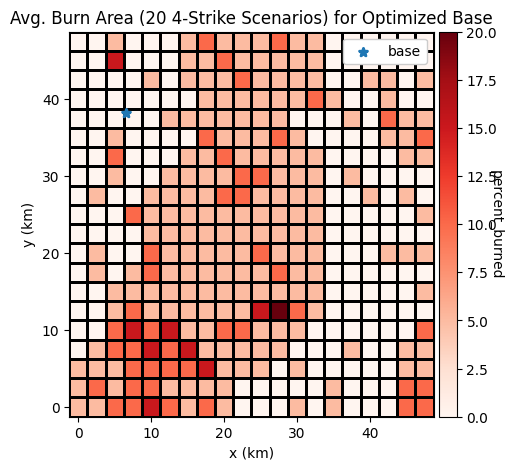

In [ ]:
bm = BurnedMap.from_problem(psp_nm)
fig, ax = bm.show(properties={'percent_burned': {'cmap': 'Reds'}},
                  title="Avg. Burn Area (20 3-Strike Scenarios) for Optimized Base")
ax.scatter(*nm_res.x, marker="*", label="base", linewidth=2.0)
ax.legend(framealpha=1.0)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")

### Experiment 2: Powell's Method

Seems to not really work, since it doesn't escape its area.

In [ ]:
from scipy.optimize import fmin_powell

psp_pow = BasePlacementProblem(replicates=20)
pow_res = fmin_powell(psp_pow.perc_burned, [10.0, 10.0], maxfun=20, retall=True, xtol=1.0)

         Current function value: 0.210375
         Iterations: 0
         Function evaluations: 20


c:\Users\dhulse\AppData\Local\anaconda3\envs\fmdtools\Lib\site-packages\scipy\optimize\_optimize.py:3322: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)


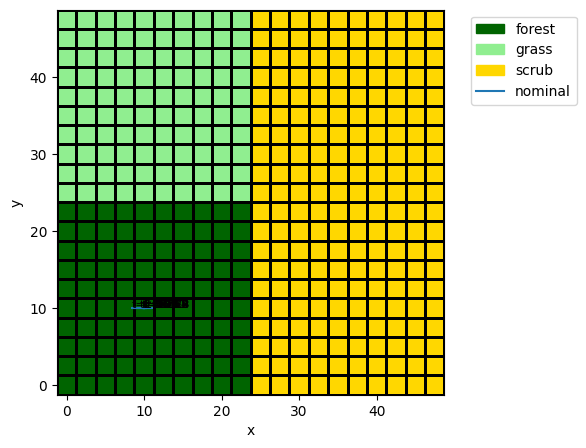

In [ ]:
fig, ax = psp_pow.mdl.flows['fireenvironment'].c.show(properties=show_properties)
fig, ax = psp_pow.iter_hist.plot_trajectories("variables.x", "variables.y", fig=fig, ax=ax, **traj_plot_kwar)

(<Figure size 300x200 with 1 Axes>,
 [<Axes: title={'center': 'objectives.perc_burned'}, xlabel='time'>])

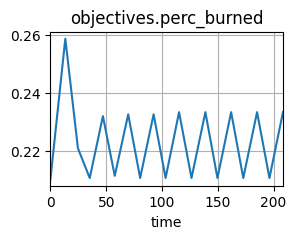

In [ ]:
psp_pow.iter_hist.plot_line("objectives.perc_burned")

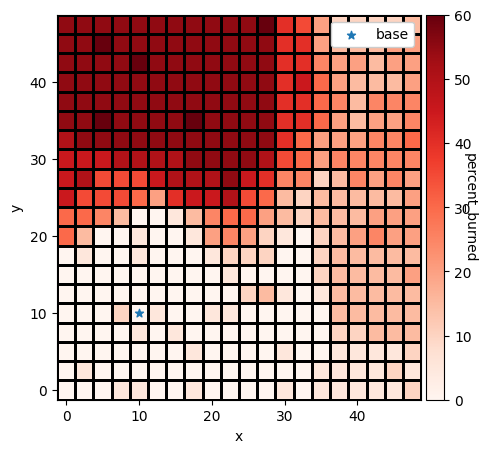

In [ ]:
bm = BurnedMap.from_problem(psp_pow)
fig, ax = bm.show(properties={'percent_burned': {'cmap': 'Reds'}})
ax.scatter(*pow_res[0], marker="*", label="base")
ax.legend(framealpha=1.0)

### Experiment 3: DIRECT

This worked pretty well at n=10 points and I expect it to work here also.

In [ ]:
from scipy.optimize import direct

psp_d = BasePlacementProblem(replicates=50)
res_d = direct(psp_d.perc_burned, [(-1.0, 47.0), (-1.0, 47.0)], maxfun=100) #maxfun = 50

In [ ]:
res_d

 message: Number of function evaluations done is larger than maxfun=100
 success: False
  status: 1
     fun: 0.022700000000000005
       x: [ 2.537e+01  2.873e+01]
     nit: 12
    nfev: 101

In [ ]:
res_d.x

array([25.37037037, 28.72839506])

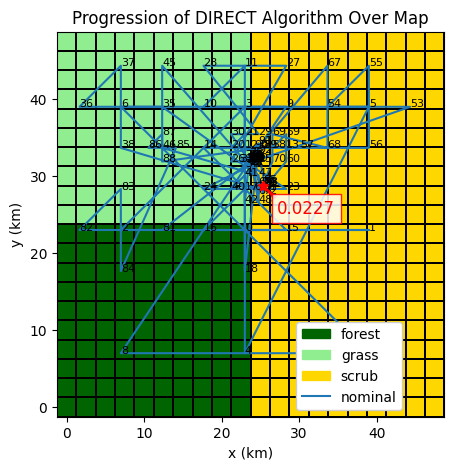

In [ ]:
from fmdtools.analyze.common import consolidate_legend
fig, ax = psp_d.mdl.flows['fireenvironment'].c.show(properties=show_properties, linewidth=0.01)
fig, ax = psp_d.iter_hist.plot_trajectories("variables.x", "variables.y", fig=fig, ax=ax, **traj_plot_kwar)
show_opt(ax, res_d, color="red", digits=4,
         xytext = (10,-20), textcoords='offset points',
         arrowprops={'width': 1, 'color': 'red', 'headwidth': 2.0},
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.85))
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
consolidate_legend(ax, bbox_to_anchor=(0.6,0), loc="lower left", framealpha=1.0)
ax.set_title("Progression of DIRECT Algorithm Over Map")
fig.savefig("optim_traj.pdf", bbox_inches='tight')

(<Figure size 300x200 with 1 Axes>,
 [<Axes: title={'center': 'objectives.perc_burned'}, xlabel='time'>])

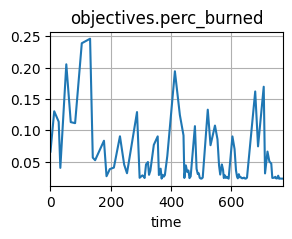

In [ ]:
psp_d.iter_hist.plot_line("objectives.perc_burned")

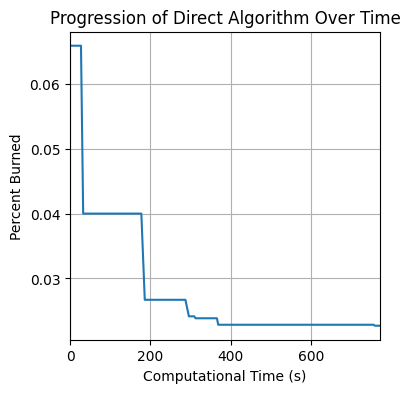

In [ ]:
objs = psp_d.iter_hist.objectives.perc_burned
psp_d.iter_hist['min_obj'] = [np.min(objs[:i]) for i in range(1, len(objs)+1)]
fig, ax = psp_d.iter_hist.plot_line("min_obj",
                                     ylabels={'min_obj': "Percent Burned"},
                                     xlabel="Computational Time (s)",
                                     figsize = (4,4),
                                     titles={'min_obj': 'Progression of Direct Algorithm Over Time'})
fig.savefig("min_d.pdf", bbox_inches='tight')

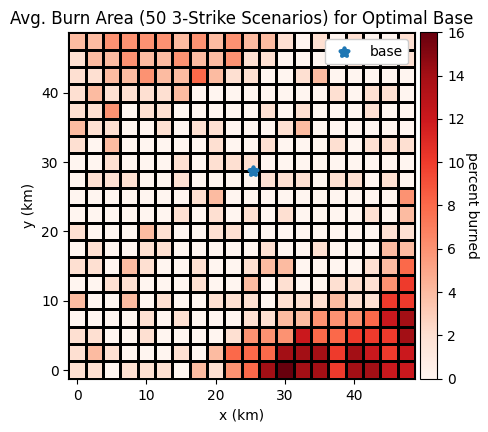

In [ ]:
bm = BurnedMap.from_problem(psp_d)
fig, ax = bm.show(properties={'percent_burned': {'cmap': 'Reds'}},
                  title="Avg. Burn Area (50 3-Strike Scenarios) for Optimal Base",
                  figsize=(5,4.5))
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.axis("square")
ax.collections[0].colorbar.set_label("percent burned", labelpad=10)
ax.scatter(*res_d.x, marker="*", label="base", linewidth=3.0)
ax.legend(framealpha=1.0)
fig.savefig("optimized_burn_area.pdf")

This result is similar (but somewhat less good) than the one from Nelder-Mead. However, it is expected that DIRECT is a less efficient algorithm, and it was much more robust over 10 replicates.

## Verification

In [ ]:
from fmdtools.define.object.coords import Coords, CoordsParam
import numpy as np


class OptimMapParam(CoordsParam):
    x_size: int = 10
    y_size: int = 10
    blocksize: float = 5.0
    state_fval: tuple = (float, 10.0)
    seed: int = 10
    replicates: int = 10


class OptimMap(Coords):
    container_p = OptimMapParam

    def init_properties(self, **kwargs):
        psp2 = BasePlacementProblem(seed=self.p.seed, replicates=self.p.replicates)
        for pt in self.pts:
            self.set(*pt, "fval", psp2.perc_burned(*pt))
            print(pt)

    def overlay_height(self, ax, fontsize=8, digits=3):
        # c_off = np.array([om.p.blocksize/2, om.p.blocksize/2])
        for pt in om.pts:
            # c_pt = np.array(pt)-c_off
            ax.text(*pt, str(round(om.get(*pt, "fval"), digits)),
                    verticalalignment='center', horizontalalignment='center',
                    fontsize=fontsize)

[0. 0.]
[ 0. 10.]
[ 0. 20.]
[ 0. 30.]
[ 0. 40.]
[10.  0.]
[10. 10.]
[10. 20.]
[10. 30.]
[10. 40.]
[20.  0.]
[20. 10.]
[20. 20.]
[20. 30.]
[20. 40.]
[30.  0.]
[30. 10.]
[30. 20.]
[30. 30.]
[30. 40.]
[40.  0.]
[40. 10.]
[40. 20.]
[40. 30.]
[40. 40.]


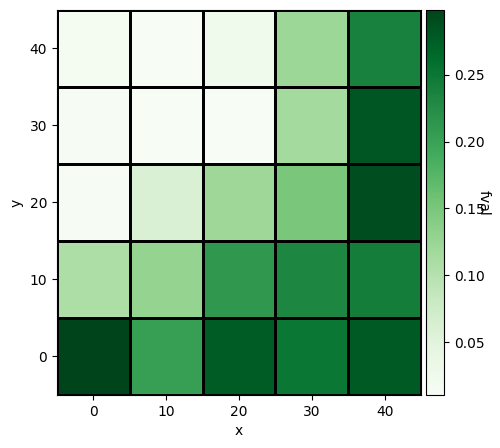

In [ ]:
om = OptimMap(p=dict(x_size=5, y_size=5, blocksize=10.0))

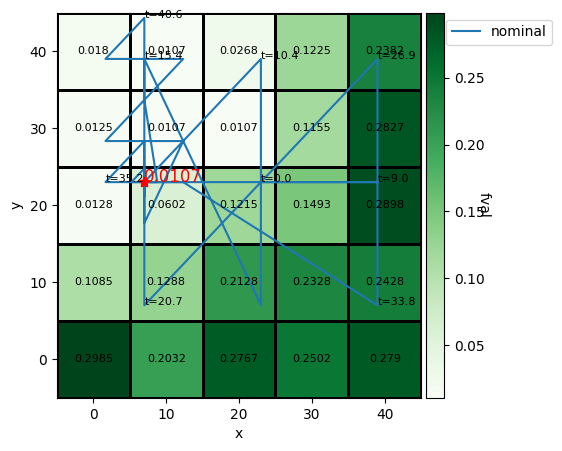

In [ ]:
fig, ax = om.show(properties={"fval": {}})
om.overlay_height(ax, digits=4)
fig, ax = psp.iter_hist.plot_trajectories("variables.x", "variables.y", time_groups=["nominal"],
                                          fig=fig, ax=ax)
show_opt(ax, res, color="red", digits=4)

Verification: How robust is this?

In [ ]:
om = OptimMap(p=dict(x_size=5, y_size=5, blocksize=10.0, seed=20))

[0. 0.]
[ 0. 10.]
[ 0. 20.]
[ 0. 30.]
[ 0. 40.]
[10.  0.]
[10. 10.]
[10. 20.]
[10. 30.]
[10. 40.]
[20.  0.]
[20. 10.]
[20. 20.]
[20. 30.]
[20. 40.]
[30.  0.]
[30. 10.]
[30. 20.]
[30. 30.]
[30. 40.]
[40.  0.]
[40. 10.]
[40. 20.]
[40. 30.]
[40. 40.]


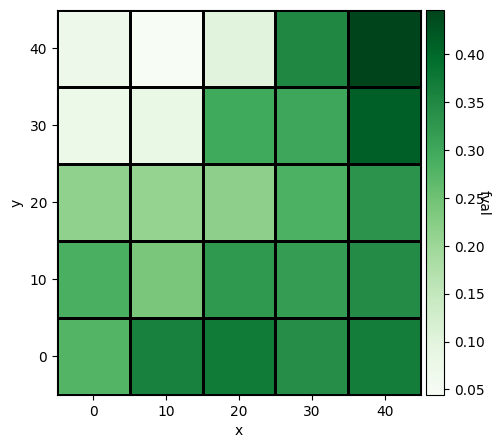

In [ ]:
fig, ax = om.show(properties={"fval": {}})

So, at n=10, there is some change to be expected re: base placement.

In [ ]:
om20 = OptimMap(p=dict(x_size=5, y_size=5, blocksize=10.0, seed=20, replicates=20))

[0. 0.]
[ 0. 10.]
[ 0. 20.]
[ 0. 30.]
[ 0. 40.]
[10.  0.]
[10. 10.]
[10. 20.]
[10. 30.]
[10. 40.]
[20.  0.]
[20. 10.]
[20. 20.]
[20. 30.]
[20. 40.]
[30.  0.]
[30. 10.]
[30. 20.]
[30. 30.]
[30. 40.]
[40.  0.]
[40. 10.]
[40. 20.]
[40. 30.]
[40. 40.]


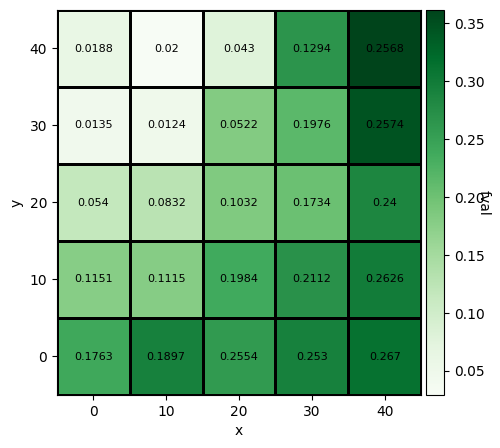

In [ ]:
fig, ax = om20.show(properties={"fval": {}})
om20.overlay_height(ax, digits=4)

In [ ]:
om21 = OptimMap(p=dict(x_size=5, y_size=5, blocksize=10.0, seed=242, replicates=20))

[0. 0.]
[ 0. 10.]
[ 0. 20.]
[ 0. 30.]
[ 0. 40.]
[10.  0.]
[10. 10.]
[10. 20.]
[10. 30.]
[10. 40.]
[20.  0.]
[20. 10.]
[20. 20.]
[20. 30.]
[20. 40.]
[30.  0.]
[30. 10.]
[30. 20.]
[30. 30.]
[30. 40.]
[40.  0.]
[40. 10.]
[40. 20.]
[40. 30.]
[40. 40.]


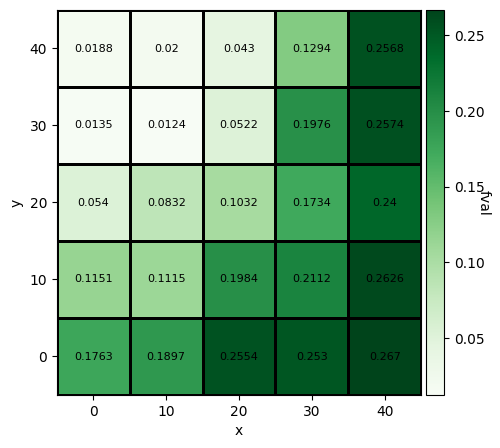

In [ ]:
fig, ax = om21.show(properties={"fval": {}})
om21.overlay_height(ax, digits=4)